<a href="https://colab.research.google.com/github/samboy2002/ISCG7424-MAD-Group-Assignment/blob/master/Sales%20Prediction_Hybrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Attempting to load data from: /content/().xlsx


/tmp/ipython-input-2583018352.py:54: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  daily_df['Avg_Daily_Discount'].fillna(0, inplace=True)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


--- Training LSTM Model (Stage 1: Base Forecast) ---
Training Complete.

--- Tuning XGBoost Corrector (Grid Search for Best Residual Fit) ---
Tuning complete after 27 runs.
Optimal XGBoost Parameters found: {'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.01} (CV RMSE: 324.88)

--- Model Performance Comparison ---
LSTM-Only RMSE: $437.86
Hybrid (Tuned) RMSE: $429.41

Conclusion: SUCCESS! The Tuned Hybrid model outperformed the LSTM-Only model (R2: 0.8429).

--- Generating 365-Day Hybrid Forecast (Future Discount Assumption: 0.1317) ---

 'future_category_predictions_v5.csv' saved (Optimized Hybrid Forecast).

--- Generating Discount Impact Analysis Data for Power BI ---
'sub_category_discount_analysis.csv' saved (Discount Strategy Data).

--- Generating Plots for Analysis ---


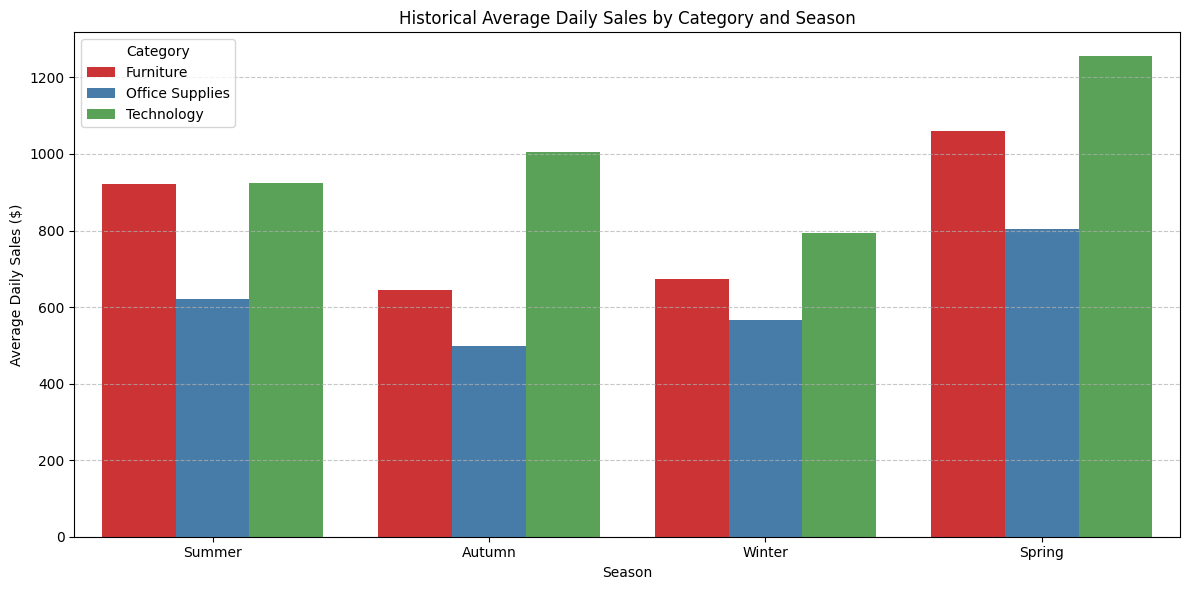

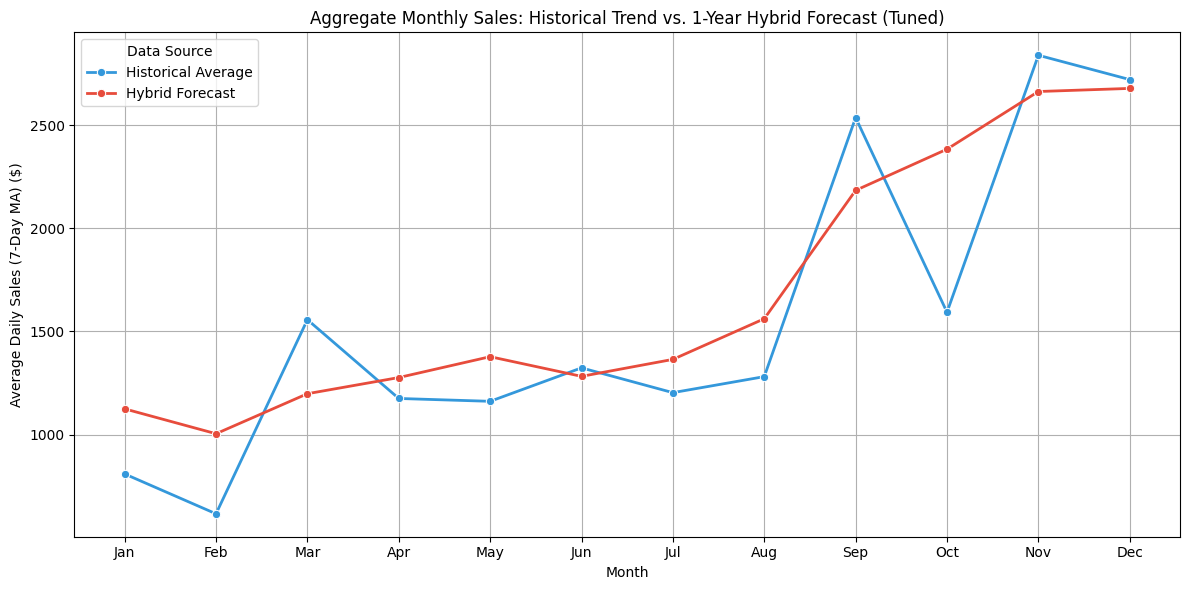

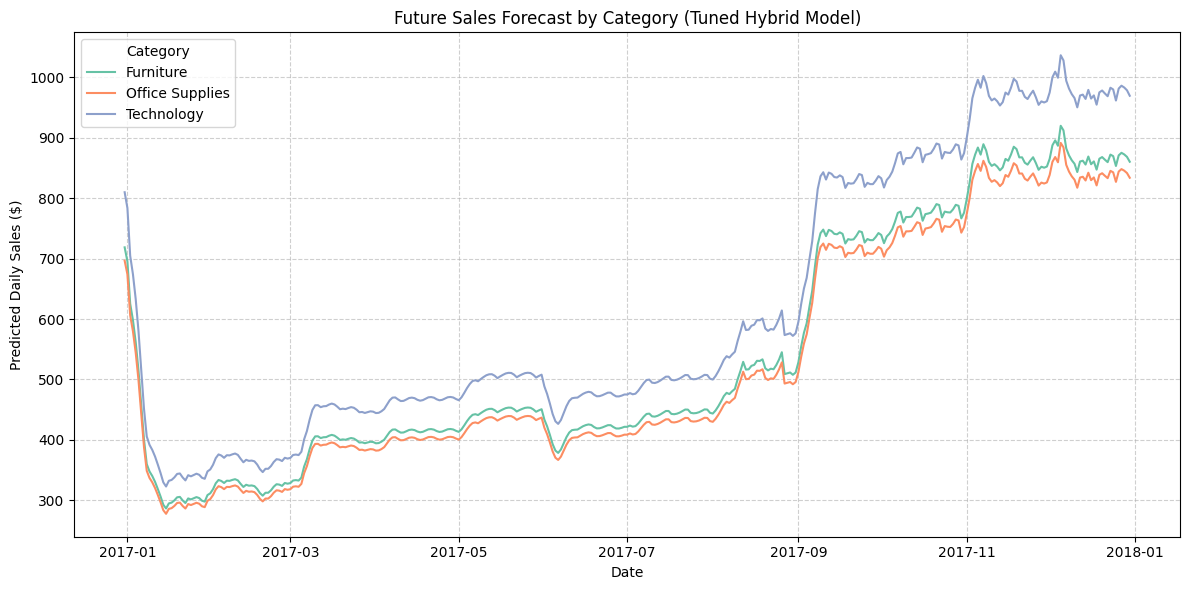

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import KFold

def get_season(month):
    """Maps month number to a season name based on the specified definition."""
    if month in [12, 1, 2]:
        return 'Summer'
    elif month in [3, 4, 5]:
        return 'Autumn'
    elif month in [6, 7, 8]:
        return 'Winter'
    else: # 9, 10, 11
        return 'Spring'


FILE_PATH = '/content/().xlsx'
print(f"Attempting to load data from: {FILE_PATH}")

try:
    df_raw = pd.read_excel(FILE_PATH)
except FileNotFoundError:
    print(f"Error: Could not find '{FILE_PATH}'. Please ensure the file is correctly uploaded.")
    raise

core_cols = ['Order Date', 'Sales', 'Category', 'Sub-Category', 'Discount']
df_raw = df_raw[core_cols].dropna(subset=core_cols)
df_raw['Order Date'] = pd.to_datetime(df_raw['Order Date'])

df_raw['Sales'] = df_raw['Sales'].astype(str).str.replace('[$,]', '', regex=True).astype(float)
df_raw['Discount'] = df_raw['Discount'].astype(float)


df_raw['Month'] = df_raw['Order Date'].dt.month
df_raw['Season'] = df_raw['Month'].apply(get_season)


daily_df = df_raw.groupby('Order Date').agg({
    'Sales': 'sum',
    'Discount': 'mean'
}).reset_index()

daily_df = daily_df.set_index('Order Date').resample('D').sum().fillna(0).reset_index()
daily_df.rename(columns={'Discount': 'Avg_Daily_Discount'}, inplace=True)

daily_df['Avg_Daily_Discount'].fillna(0, inplace=True)

daily_df['Sales_MA'] = daily_df['Sales'].rolling(window=7).mean().fillna(0)

daily_df['DayOfWeek'] = daily_df['Order Date'].dt.dayofweek
daily_df['Month'] = daily_df['Order Date'].dt.month
daily_df['Season'] = daily_df['Month'].apply(get_season)

season_map = {'Summer': 0, 'Autumn': 1, 'Winter': 2, 'Spring': 3}
daily_df['Season_Encoded'] = daily_df['Season'].map(season_map)

features_list = ['Sales_MA', 'DayOfWeek', 'Month', 'Season_Encoded', 'Avg_Daily_Discount']
scaler = MinMaxScaler()
scaled = scaler.fit_transform(daily_df[features_list].values)
scaled_df = pd.DataFrame(scaled, columns=features_list)

window_size = 60

def create_sequences(data, window_size=window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_df.values, window_size=window_size)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


n_features = X.shape[2]
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X.shape[1], n_features)),
    Dropout(0.2),
    LSTM(64),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

print("--- Training LSTM Model (Stage 1: Base Forecast) ---")
model.fit(X_train, y_train, epochs=75, batch_size=16, validation_split=0.1, verbose=0)
print("Training Complete.")



y_train_actual = daily_df['Sales_MA'].values[window_size:split + window_size]
y_train_lstm_scaled = model.predict(X_train, verbose=0)
X_train_last_step = X_train[:, -1, 1:]
y_train_lstm_full = np.concatenate([y_train_lstm_scaled, X_train_last_step], axis=1)
y_train_lstm_pred_unscaled = scaler.inverse_transform(y_train_lstm_full)[:, 0]
residuals_train = y_train_actual - y_train_lstm_pred_unscaled

xgb_features_list = ['DayOfWeek', 'Month', 'Season', 'Avg_Daily_Discount']
df_xgb_train = daily_df.iloc[window_size:split + window_size].copy().reset_index(drop=True)

ct = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['Season'])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)
X_xgb_train_aux = ct.fit_transform(df_xgb_train[xgb_features_list])
feature_names = list(ct.get_feature_names_out())
X_xgb_train_df = pd.DataFrame(X_xgb_train_aux, columns=feature_names)
X_xgb_train_df['LSTM_Pred'] = y_train_lstm_pred_unscaled

print("\n--- Tuning XGBoost Corrector (Grid Search for Best Residual Fit) ---")
best_rmse = np.inf
best_params = {}

param_grid = {
    'n_estimators': [150, 300, 500],
    'max_depth': [5, 8, 10],
    'learning_rate': [0.1, 0.05, 0.01]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
tuning_runs = 0

for n_est in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        for lr in param_grid['learning_rate']:
            tuning_runs += 1
            fold_rmses = []

            for train_index, val_index in kf.split(X_xgb_train_df):
                X_train_fold, X_val_fold = X_xgb_train_df.iloc[train_index], X_xgb_train_df.iloc[val_index]
                y_train_fold, y_val_fold = residuals_train[train_index], residuals_train[val_index]

                xgb_candidate = XGBRegressor(
                    objective='reg:squarederror',
                    n_estimators=n_est,
                    max_depth=depth,
                    learning_rate=lr,
                    random_state=42,
                    verbosity=0
                )
                xgb_candidate.fit(X_train_fold, y_train_fold)
                val_predictions = xgb_candidate.predict(X_val_fold)
                fold_rmses.append(np.sqrt(mean_squared_error(y_val_fold, val_predictions)))

            avg_rmse = np.mean(fold_rmses)

            if avg_rmse < best_rmse:
                best_rmse = avg_rmse
                best_params = {'n_estimators': n_est, 'max_depth': depth, 'learning_rate': lr}

print(f"Tuning complete after {tuning_runs} runs.")
print(f"Optimal XGBoost Parameters found: {best_params} (CV RMSE: {best_rmse:.2f})")

final_xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params, verbosity=0)
final_xgb_model.fit(X_xgb_train_df, residuals_train)


y_test_actual_unscaled = daily_df['Sales_MA'].values[split + window_size:]
y_test_lstm_scaled = model.predict(X_test, verbose=0)
X_test_last_step = X_test[:, -1, 1:]
y_test_lstm_full = np.concatenate([y_test_lstm_scaled, X_test_last_step], axis=1)
y_test_lstm_pred_unscaled = scaler.inverse_transform(y_test_lstm_full)[:, 0]

df_xgb_test = daily_df.iloc[split + window_size:].copy().reset_index(drop=True)
X_xgb_test_aux = ct.transform(df_xgb_test[xgb_features_list])
X_xgb_test_df = pd.DataFrame(X_xgb_test_aux, columns=feature_names)
X_xgb_test_df['LSTM_Pred'] = y_test_lstm_pred_unscaled
r_xgb_test_pred = final_xgb_model.predict(X_xgb_test_df)
y_test_hybrid_pred_unscaled = y_test_lstm_pred_unscaled + r_xgb_test_pred

rmse_lstm = np.sqrt(mean_squared_error(y_test_actual_unscaled, y_test_lstm_pred_unscaled))
rmse_hybrid = np.sqrt(mean_squared_error(y_test_actual_unscaled, y_test_hybrid_pred_unscaled))
r2_hybrid = r2_score(y_test_actual_unscaled, y_test_hybrid_pred_unscaled)

print(f"\n--- Model Performance Comparison ---")
print(f"LSTM-Only RMSE: ${rmse_lstm:.2f}")
print(f"Hybrid (Tuned) RMSE: ${rmse_hybrid:.2f}")

if rmse_hybrid < rmse_lstm:
    print(f"\nConclusion: SUCCESS! The Tuned Hybrid model outperformed the LSTM-Only model (R2: {r2_hybrid:.4f}).")
else:
    print("\nConclusion: The Tuned Hybrid model did NOT outperform the LSTM-Only model on the test set.")



future_days = 365
last_date = daily_df['Order Date'].max()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=future_days)
historical_avg_discount = daily_df['Avg_Daily_Discount'].mean()

future_aux_df = pd.DataFrame({'Order Date': future_dates})
future_aux_df['DayOfWeek'] = future_aux_df['Order Date'].dt.dayofweek
future_aux_df['Month_Num'] = future_aux_df['Order Date'].dt.month
future_aux_df['Season'] = future_aux_df['Month_Num'].apply(get_season)
future_aux_df['Season_Encoded'] = future_aux_df['Season'].map(season_map)
future_aux_df['Avg_Daily_Discount'] = historical_avg_discount

aux_features_to_scale = ['DayOfWeek', 'Month_Num', 'Season_Encoded', 'Avg_Daily_Discount']
feature_values_to_scale = future_aux_df[aux_features_to_scale].values
dummy_sales_col = np.zeros((future_days, 1))
features_for_scaler = np.hstack((dummy_sales_col, feature_values_to_scale))
future_scaled_full = scaler.transform(features_for_scaler)
future_aux_scaled_features = future_scaled_full[:, 1:]

current_seq = scaled_df.values[-window_size:].copy()
hybrid_future_predictions = []

print(f"\n--- Generating 365-Day Hybrid Forecast (Future Discount Assumption: {historical_avg_discount:.4f}) ---")
for i in range(future_days):
    lstm_pred_scaled = model.predict(current_seq.reshape(1, window_size, n_features), verbose=0)[0, 0]
    new_aux_scaled = future_aux_scaled_features[i, :]
    lstm_pred_full = np.hstack((np.array([lstm_pred_scaled]).reshape(1, 1), new_aux_scaled.reshape(1, -1)))
    lstm_pred_unscaled = scaler.inverse_transform(lstm_pred_full)[:, 0]

    xgb_input_date = future_aux_df.iloc[[i]].copy()
    xgb_input_date.rename(columns={'Month_Num': 'Month'}, inplace=True)
    X_xgb_pred_aux = ct.transform(xgb_input_date[xgb_features_list])
    X_xgb_pred_df = pd.DataFrame(X_xgb_pred_aux, columns=feature_names)
    X_xgb_pred_df['LSTM_Pred'] = lstm_pred_unscaled

    r_xgb_pred = final_xgb_model.predict(X_xgb_pred_df)[0]

    hybrid_pred_unscaled = lstm_pred_unscaled + r_xgb_pred
    hybrid_future_predictions.append(hybrid_pred_unscaled)

    features_to_scale = np.hstack((
        np.array([hybrid_pred_unscaled]).reshape(1, 1),
        feature_values_to_scale[i, :].reshape(1, -1)
    ))
    hybrid_pred_full_scaled = scaler.transform(features_to_scale)
    hybrid_pred_scaled_for_next_step = hybrid_pred_full_scaled[0, 0]

    new_row = np.array([hybrid_pred_scaled_for_next_step, *new_aux_scaled])
    current_seq = np.vstack((current_seq[1:], new_row))



category_sales_total = df_raw.groupby('Category')['Sales'].sum()
overall_total_sales = category_sales_total.sum()
category_proportions = category_sales_total / overall_total_sales

future_hybrid_df = pd.DataFrame({
    'Date': future_dates,
    'Season': future_aux_df['Season'],
    'Month': future_aux_df['Order Date'].dt.strftime('%b'),
    'Predicted_Sales_Aggregate': np.array(hybrid_future_predictions).flatten()
})

final_predictions_list = []
for index, row in future_hybrid_df.iterrows():
    for category, proportion in category_proportions.items():
        final_predictions_list.append({
            'Date': row['Date'],
            'Season': row['Season'],
            'Month': row['Month'],
            'Category': category,
            'Predicted_Sales': row['Predicted_Sales_Aggregate'] * proportion,
            'Aggregate_Sales': row['Predicted_Sales_Aggregate']
        })

final_category_predictions_df = pd.DataFrame(final_predictions_list)
final_category_predictions_df.to_csv('future_category_predictions_v5.csv', index=False)
print("\n 'future_category_predictions_v5.csv' saved (Optimized Hybrid Forecast).")



print("\n--- Generating Discount Impact Analysis Data for Power BI ---")

discounted_sales = df_raw[df_raw['Discount'] > 0].copy()
undiscounted_sales = df_raw[df_raw['Discount'] == 0].copy()

avg_sales_discounted = discounted_sales.groupby('Sub-Category')['Sales'].mean().reset_index()
avg_sales_discounted.rename(columns={'Sales': 'Avg_Sales_Discounted'}, inplace=True)

avg_sales_undiscounted = undiscounted_sales.groupby('Sub-Category')['Sales'].mean().reset_index()
avg_sales_undiscounted.rename(columns={'Sales': 'Avg_Sales_Undiscounted'}, inplace=True)

discount_impact_df = pd.merge(avg_sales_undiscounted, avg_sales_discounted, on='Sub-Category', how='outer').fillna(0)

discount_impact_df['Sales_Uplift_Absolute'] = discount_impact_df['Avg_Sales_Discounted'] - discount_impact_df['Avg_Sales_Undiscounted']
discount_impact_df['Sales_Uplift_Percentage'] = np.where(
    discount_impact_df['Avg_Sales_Undiscounted'] > 0,
    (discount_impact_df['Sales_Uplift_Absolute'] / discount_impact_df['Avg_Sales_Undiscounted']) * 100,
    0
)

discount_impact_df.replace([np.inf, -np.inf], 0, inplace=True)
discount_impact_df['Sales_Uplift_Percentage'] = discount_impact_df['Sales_Uplift_Percentage'].round(2)
discount_impact_df['Sales_Uplift_Absolute'] = discount_impact_df['Sales_Uplift_Absolute'].round(2)
discount_impact_df['Avg_Sales_Discounted'] = discount_impact_df['Avg_Sales_Discounted'].round(2)
discount_impact_df['Avg_Sales_Undiscounted'] = discount_impact_df['Avg_Sales_Undiscounted'].round(2)

discount_impact_df.to_csv('sub_category_discount_analysis.csv', index=False)
print("'sub_category_discount_analysis.csv' saved (Discount Strategy Data).")



print("\n--- Generating Plots for Analysis ---")

seasonal_sales_summary = df_raw.groupby(['Category', 'Season'])['Sales'].sum().reset_index()
days_in_season = df_raw.groupby(['Category', 'Season'])['Order Date'].nunique().reset_index()
seasonal_analysis_df = pd.merge(seasonal_sales_summary, days_in_season, on=['Category', 'Season'])
seasonal_analysis_df['Average Daily Sales'] = seasonal_analysis_df['Sales'] / seasonal_analysis_df['Order Date']

SEASON_ORDER = ['Summer', 'Autumn', 'Winter', 'Spring']
seasonal_analysis_df['Season'] = pd.Categorical(seasonal_analysis_df['Season'], categories=SEASON_ORDER, ordered=True)
seasonal_analysis_df = seasonal_analysis_df.sort_values(['Category', 'Season'])

plt.figure(figsize=(12, 6))
sns.barplot(x='Season', y='Average Daily Sales', hue='Category', data=seasonal_analysis_df, palette='Set1')
plt.title('Historical Average Daily Sales by Category and Season')
plt.xlabel('Season')
plt.ylabel('Average Daily Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Category', loc='upper left')
plt.tight_layout()
plt.show()

historical_monthly_avg = daily_df.copy()
historical_monthly_avg['Month'] = historical_monthly_avg['Order Date'].dt.strftime('%b')
historical_monthly_avg = historical_monthly_avg.groupby('Month')['Sales_MA'].mean().reset_index()
historical_monthly_avg.rename(columns={'Sales_MA': 'Average Sales'}, inplace=True)
historical_monthly_avg['Type'] = 'Historical Average'

forecast_monthly_avg = future_hybrid_df.groupby('Month')['Predicted_Sales_Aggregate'].mean().reset_index()
forecast_monthly_avg.rename(columns={'Predicted_Sales_Aggregate': 'Average Sales'}, inplace=True)
forecast_monthly_avg['Type'] = 'Hybrid Forecast'

combined_monthly_df = pd.concat([historical_monthly_avg, forecast_monthly_avg])
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
combined_monthly_df['Month'] = pd.Categorical(combined_monthly_df['Month'], categories=month_order, ordered=True)
combined_monthly_df = combined_monthly_df.sort_values('Month')

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month', y='Average Sales', hue='Type', data=combined_monthly_df, marker='o', palette=['#3498db', '#e74c3c'], linewidth=2)
plt.title('Aggregate Monthly Sales: Historical Trend vs. 1-Year Hybrid Forecast (Tuned)')
plt.xlabel('Month')
plt.ylabel('Average Daily Sales (7-Day MA) ($)')
plt.grid(True)
plt.legend(title='Data Source')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(x='Date', y='Predicted_Sales', hue='Category', data=final_category_predictions_df, palette='Set2')
plt.title('Future Sales Forecast by Category (Tuned Hybrid Model)')
plt.xlabel('Date')
plt.ylabel('Predicted Daily Sales ($)')
plt.legend(title='Category')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
